In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from train_test_split import load_grouped_splits
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import lightgbm as lgb

## Load premade splits
`python
data = tuple(X_train, y_train, X_val, y_val, X_test, y_test, class_names)

In [2]:
data = load_grouped_splits()
X_train, y_train, X_val, y_val, X_test, y_test, classes = data

# Concatenate training and validation sets to do CV on combined set
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))
print(X_train_val.shape)
print(X_train.shape)
print("Classes:")
print(data[-1])

Train size: 96
Validation size: 24
Test size: 32
(120, 16384)
(96, 16384)
Classes:
['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']


## Grid Search Parameters

In [3]:
# Define PCA variance thresholds to test
pca_variances = [0.90, 0.95, 0.99]
print(f"PCA variance thresholds to test: {pca_variances}")
print(f"Training data shape: {X_train_val.shape}")

PCA variance thresholds to test: [0.9, 0.95, 0.99]
Training data shape: (120, 16384)


## Helper Function for Model Evaluation

In [16]:
def evaluate_grid_search(name, grid_search, X_test, y_test, classes):
    """Evaluate a grid search model and print metrics."""
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    
    # Best parameters
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")
    
    # Make predictions on test set
    y_pred = grid_search.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\nTest Accuracy: {acc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return acc, y_pred, grid_search.best_params_

## 1. AdaBoost with Decision Tree

Running Grid Search for AdaBoost (Decision Tree)...



AdaBoost (Decision Tree)

Best parameters: {'classifier__estimator__max_depth': 3, 'classifier__learning_rate': 0.5, 'classifier__n_estimators': 100, 'pca__n_components': 0.9}
Best CV score: 0.3750

Test Accuracy: 0.2812

Classification Report:
              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.00      0.00      0.00         4
        Fear       0.25      0.50      0.33         4
       Happy       0.67      0.50      0.57         4
     Neutral       0.29      0.50      0.36         4
         Sad       0.18      0.50      0.27         4
   Surprised       1.00      0.25      0.40         4

    accuracy                           0.28        32
   macro avg       0.30      0.28      0.24        32
weighted avg       0.30      0.28      0.24        32


Confusion Matrix:
[[0 0 0 1 1 1 1 0]
 [0 0 0 1 0 1 2 0]
 [0 1 0 2 0 0 1 0]
 [0 0 0 2 0 0 2 0]
 [1 0 0 

c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

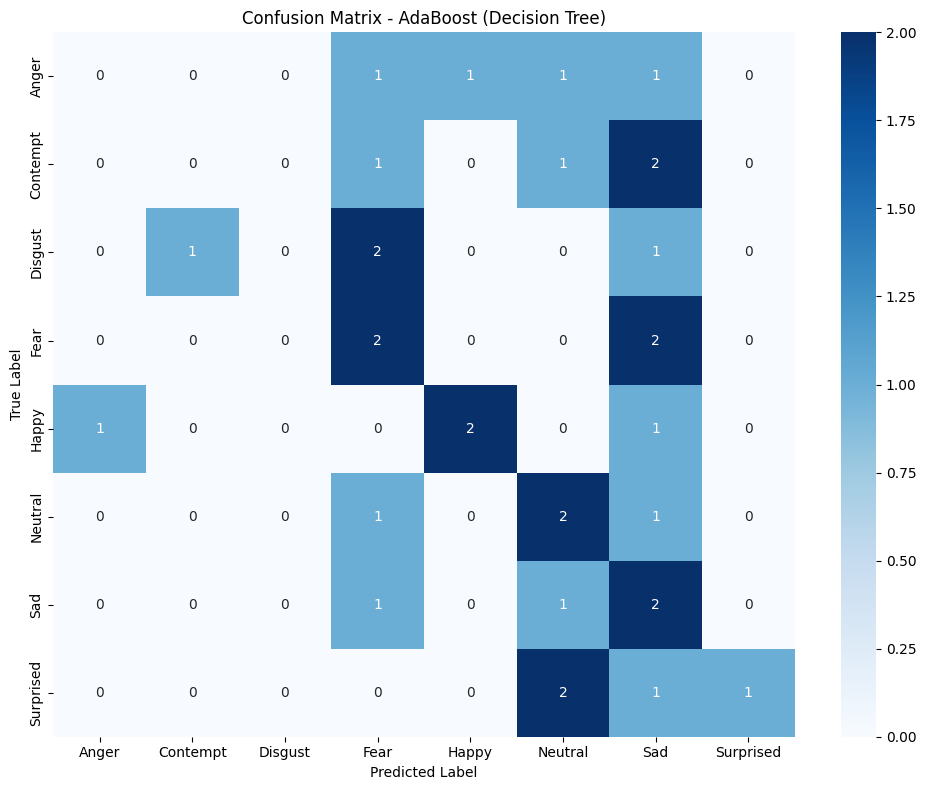

In [17]:
# AdaBoost with Decision Tree base estimator
pipeline_ada_dt = Pipeline([
    ('pca', PCA(random_state=42)),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

param_grid_ada_dt = {
    'pca__n_components': pca_variances,
    'classifier__estimator__max_depth': [1, 2, 3, 5],
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.1, 0.5, 1.0, 1.5]
}

print("Running Grid Search for AdaBoost (Decision Tree)...")
grid_ada_dt = GridSearchCV(
    pipeline_ada_dt,
    param_grid_ada_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_ada_dt.fit(X_train_val, y_train_val)
acc_ada_dt, pred_ada_dt, params_ada_dt = evaluate_grid_search(
    "AdaBoost (Decision Tree)",
    grid_ada_dt,
    X_test,
    y_test,
    classes
)

## 2. AdaBoost with SVM

Running Grid Search for AdaBoost (SVM)...
Note: This may take longer due to SVM base estimator


c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



AdaBoost (SVM)

Best parameters: {'classifier__estimator__C': 0.1, 'classifier__estimator__kernel': 'linear', 'classifier__learning_rate': 1.5, 'classifier__n_estimators': 50, 'pca__n_components': 0.9}
Best CV score: 0.3083

Test Accuracy: 0.3750

Classification Report:
              precision    recall  f1-score   support

       Anger       0.27      0.75      0.40         4
    Contempt       0.20      0.25      0.22         4
     Disgust       0.40      0.50      0.44         4
        Fear       0.50      0.25      0.33         4
       Happy       1.00      0.50      0.67         4
     Neutral       0.40      0.50      0.44         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.50      0.25      0.33         4

    accuracy                           0.38        32
   macro avg       0.41      0.38      0.36        32
weighted avg       0.41      0.38      0.36        32


Confusion Matrix:
[[3 0 1 0 0 0 0 0]
 [3 1 0 0 0 0 0 0]
 [1 1 2 0 0 0 0 0]
 

c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

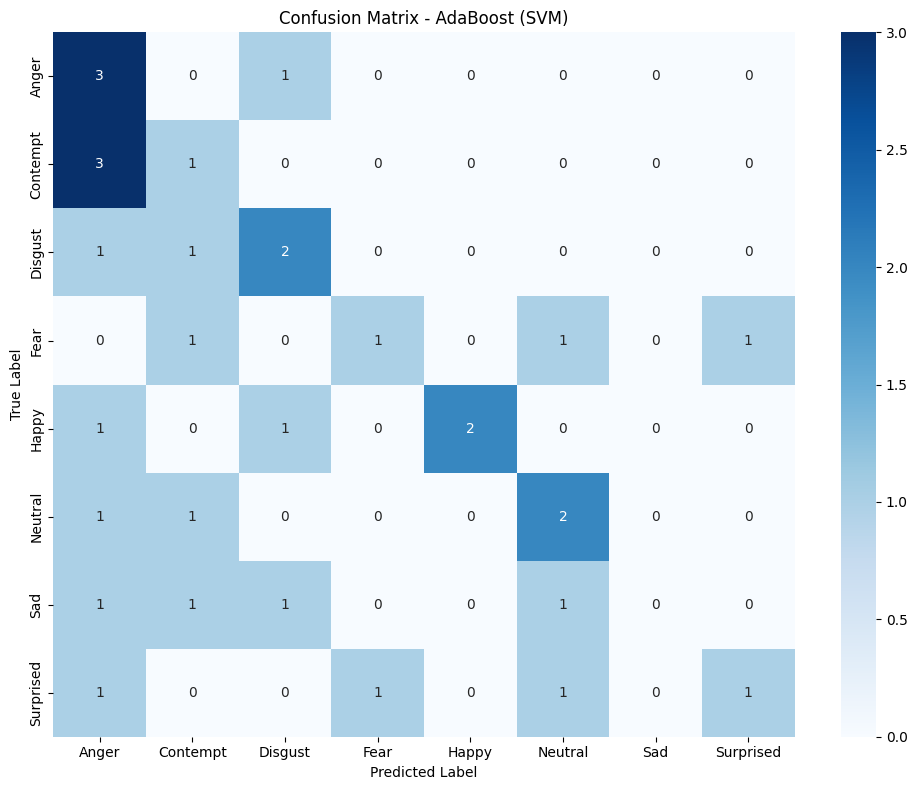

In [18]:
# AdaBoost with SVM base estimator (fewer estimators - SVM is slow)
pipeline_ada_svm = Pipeline([
    ('pca', PCA(random_state=42)),
    ('classifier', AdaBoostClassifier(
        estimator=SVC(probability=True, random_state=42),
        random_state=42,
        algorithm='SAMME'
    ))
])

param_grid_ada_svm = {
    'pca__n_components': pca_variances,
    'classifier__estimator__kernel': ['linear', 'rbf'],
    'classifier__estimator__C': [0.1, 1.0, 10.0],
    'classifier__n_estimators': [25, 50, 75],
    'classifier__learning_rate': [0.5, 1.0, 1.5]
}

print("Running Grid Search for AdaBoost (SVM)...")
print("Note: This may take longer due to SVM base estimator")

grid_ada_svm = GridSearchCV(
    pipeline_ada_svm,
    param_grid_ada_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_ada_svm.fit(X_train_val, y_train_val)
acc_ada_svm, pred_ada_svm, params_ada_svm = evaluate_grid_search(
    "AdaBoost (SVM)",
    grid_ada_svm,
    X_test,
    y_test,

    classes)

## 3. Gradient Boosting

Running Grid Search for Gradient Boosting...

Gradient Boosting

Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0, 'pca__n_components': 0.9}
Best CV score: 0.2917

Test Accuracy: 0.2500

Classification Report:
              precision    recall  f1-score   support

       Anger       0.33      0.25      0.29         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.25      0.25      0.25         4
        Fear       0.33      0.50      0.40         4
       Happy       0.38      0.75      0.50         4
     Neutral       0.00      0.00      0.00         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.50      0.25      0.33         4

    accuracy                           0.25        32
   macro avg       0.22      0.25      0.22        32
weighted avg       0.22      0.25      0.22        32


Confusion

c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

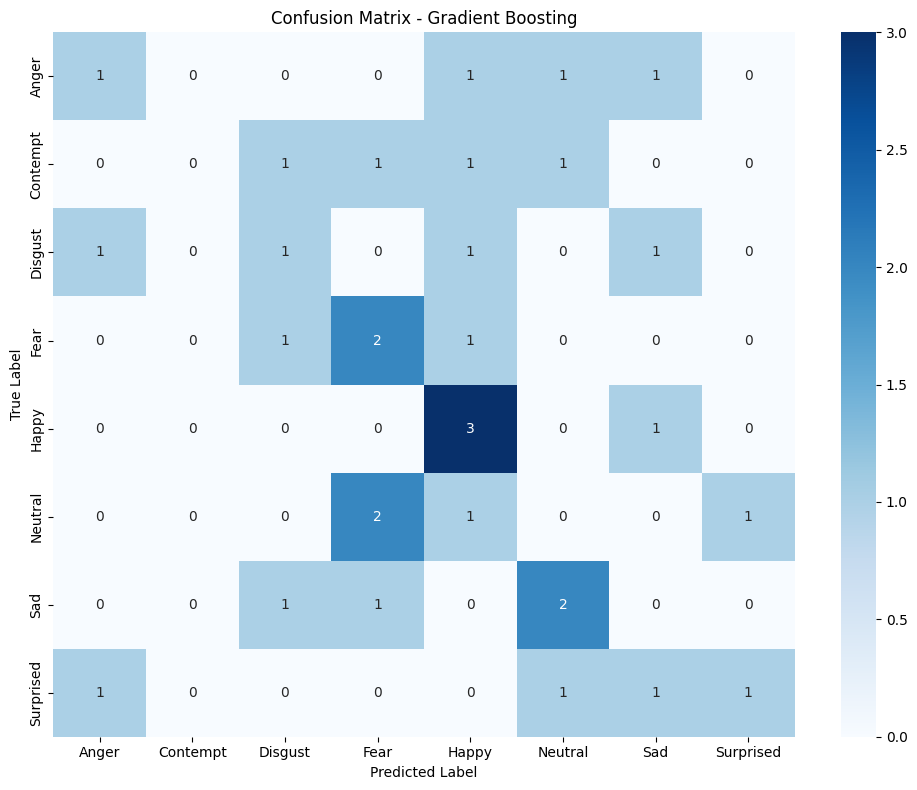

In [19]:
# Gradient Boosting Classifier
pipeline_gb = Pipeline([
    ('pca', PCA(random_state=42)),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'pca__n_components': pca_variances,
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_samples_split': [2, 5],
    'classifier__subsample': [0.8, 1.0]
}

print("Running Grid Search for Gradient Boosting...")
grid_gb = GridSearchCV(
    pipeline_gb,
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train_val, y_train_val)
acc_gb, pred_gb, params_gb = evaluate_grid_search(
    "Gradient Boosting",
    grid_gb,
    X_test,
    y_test,

    classes)

## 4. XGBoost

Running Grid Search for XGBoost...

XGBoost

Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0, 'pca__n_components': 0.9}
Best CV score: 0.3750

Test Accuracy: 0.2812

Classification Report:
              precision    recall  f1-score   support

       Anger       0.25      0.25      0.25         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.50      0.25      0.33         4
        Fear       0.50      0.25      0.33         4
       Happy       0.29      0.50      0.36         4
     Neutral       0.29      0.50      0.36         4
         Sad       0.17      0.25      0.20         4
   Surprised       0.33      0.25      0.29         4

    accuracy                           0.28        32
   macro avg       0.29      0.28      0.27        32
weighted avg       0.29      0.28      0.27      

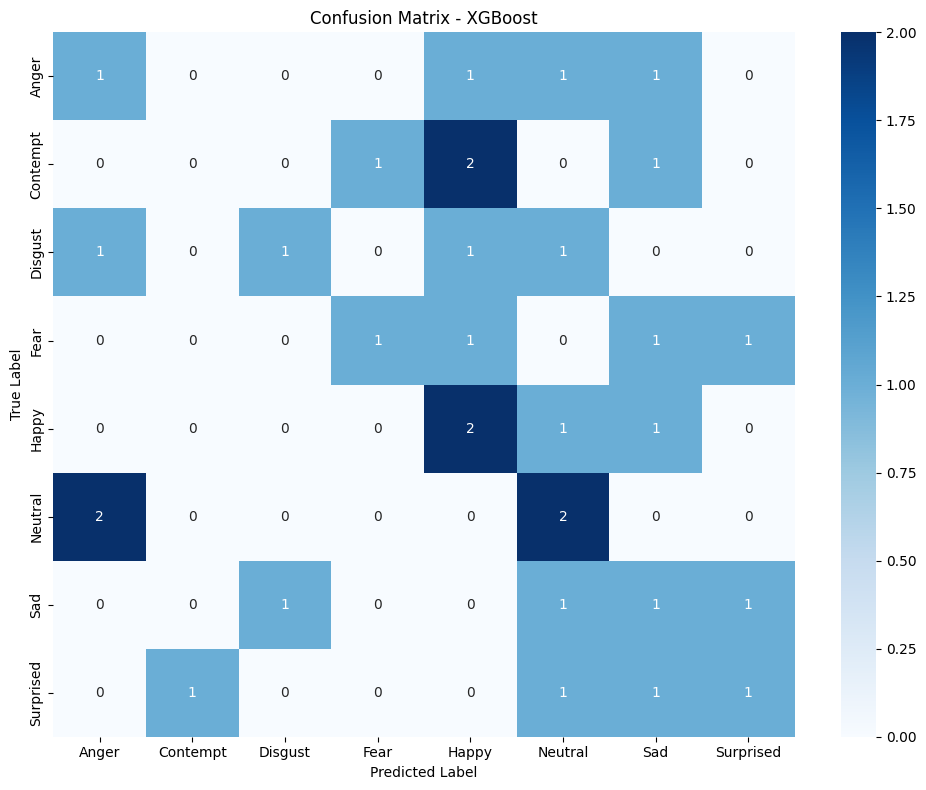

In [20]:
# XGBoost Classifier
pipeline_xgb = Pipeline([
    ('pca', PCA(random_state=42)),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid_xgb = {
    'pca__n_components': pca_variances,
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__min_child_weight': [1, 3],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

print("Running Grid Search for XGBoost...")
grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train_val, y_train_val)
acc_xgb, pred_xgb, params_xgb = evaluate_grid_search(
    "XGBoost",
    grid_xgb,
    X_test,

    y_test,
    classes)

## 5. LightGBM

Running Grid Search for LightGBM...

LightGBM

Best parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 100, 'classifier__num_leaves': 15, 'classifier__subsample': 0.8, 'pca__n_components': 0.9}
Best CV score: 0.3417

Test Accuracy: 0.3125

Classification Report:
              precision    recall  f1-score   support

       Anger       0.40      0.50      0.44         4
    Contempt       0.50      0.25      0.33         4
     Disgust       0.50      0.25      0.33         4
        Fear       0.50      0.25      0.33         4
       Happy       0.25      0.50      0.33         4
     Neutral       0.67      0.50      0.57         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.33      0.25      0.29         4

    accuracy                           0.31        32
   macro avg       0.39      0.31      0.33        32
weighted avg       0.39      0.31      0.33        

c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


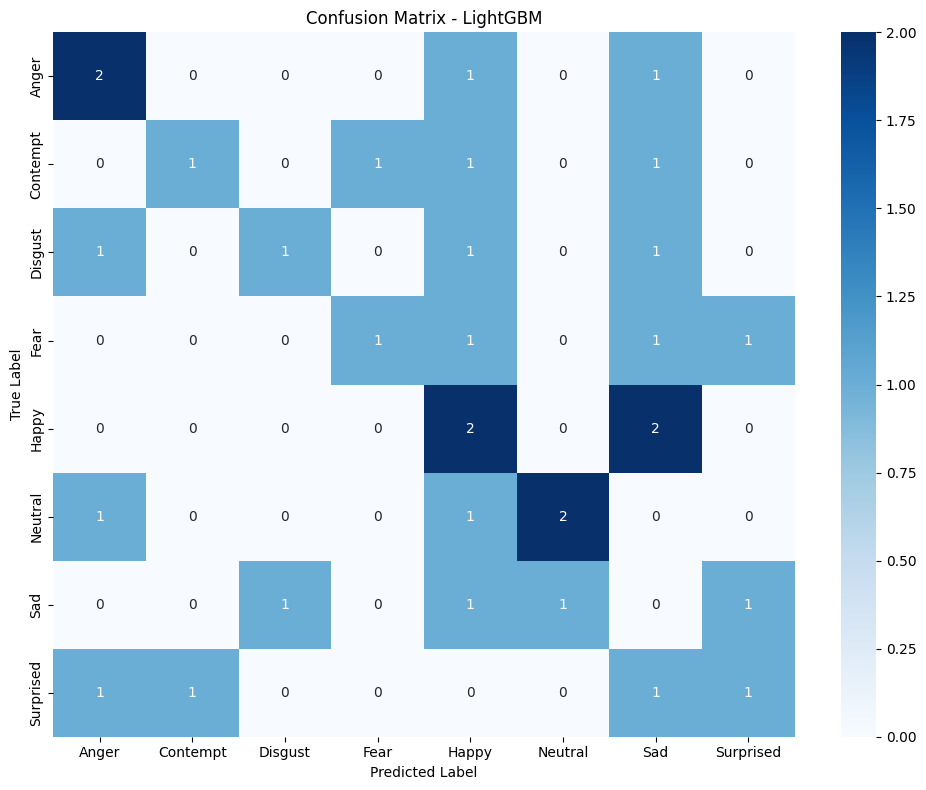

In [22]:
# LightGBM Classifier
pipeline_lgb = Pipeline([
    ('pca', PCA(random_state=42)),
    ('classifier', lgb.LGBMClassifier(random_state=42, verbose=-1))
])

param_grid_lgb = {
    'pca__n_components': pca_variances,
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__num_leaves': [15, 31, 63],
    'classifier__min_child_samples': [10, 20],
    'classifier__subsample': [0.8, 1.0]
}

print("Running Grid Search for LightGBM...")
grid_lgb = GridSearchCV(
    pipeline_lgb,
    param_grid_lgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lgb.fit(X_train_val, y_train_val)
acc_lgb, pred_lgb, params_lgb = evaluate_grid_search(
    "LightGBM",
    grid_lgb,
    X_test,

    y_test,
    classes)

## Summary Comparison


BOOSTING METHODS COMPARISON
            Model  Test Accuracy
   AdaBoost (SVM)        0.37500
         LightGBM        0.31250
    AdaBoost (DT)        0.28125
          XGBoost        0.28125
Gradient Boosting        0.25000


C:\Users\baklu\AppData\Local\Temp\ipykernel_27468\3419886584.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='Test Accuracy', palette='viridis')


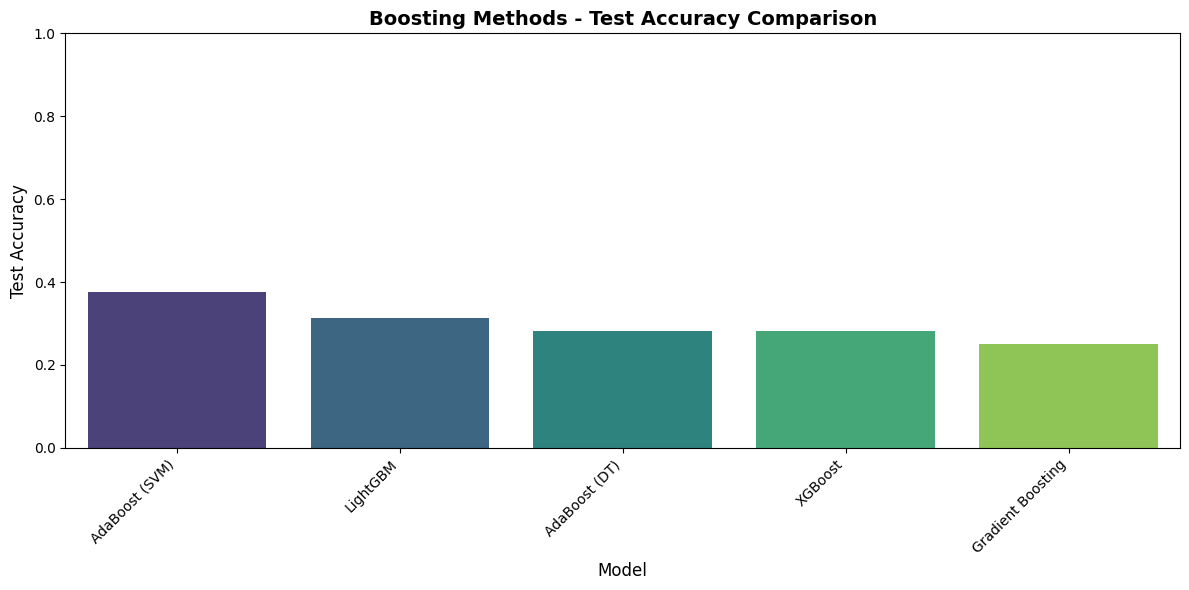

In [23]:
# Create summary DataFrame
results = pd.DataFrame({
    'Model': ['AdaBoost (DT)', 'AdaBoost (SVM)', 'Gradient Boosting', 'XGBoost', 'LightGBM'],
    'Test Accuracy': [acc_ada_dt, acc_ada_svm, acc_gb, acc_xgb, acc_lgb]
})

results = results.sort_values('Test Accuracy', ascending=False)
print("\n" + "="*60)
print("BOOSTING METHODS COMPARISON")
print("="*60)
print(results.to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=results, x='Model', y='Test Accuracy', palette='viridis')
plt.title('Boosting Methods - Test Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim([0, 1])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Best Parameters Summary

In [ ]:
# Display best parameters for all models
print("\n" + "="*60)
print("BEST PARAMETERS FOR EACH MODEL")
print("="*60)

params_summary = pd.DataFrame([
    {'Model': 'AdaBoost (DT)', **params_ada_dt},
    {'Model': 'AdaBoost (SVM)', **params_ada_svm},
    {'Model': 'Gradient Boosting', **params_gb},
    {'Model': 'XGBoost', **params_xgb},
    {'Model': 'LightGBM', **params_lgb}
])

print(params_summary.to_string(index=False))


BEST PARAMETERS FOR EACH MODEL
            Model  classifier__learning_rate  classifier__n_estimators  pca__n_components  classifier__max_depth
    AdaBoost (DT)                       0.50                       100               0.90                    NaN
   AdaBoost (SVM)                       0.50                        25               0.90                    NaN
Gradient Boosting                       0.10                       100               0.99                    3.0
          XGBoost                       0.05                       100               0.90                    3.0
         LightGBM                       0.05                        50               0.90                    5.0


## Baseline: SVM with Best Configuration
Test the SVM configuration that performed best in previous experiments (RBF kernel, C=1000, gamma=0.1) for comparison with boosting methods.

Training SVM baseline (RBF kernel, C=1000, gamma=0.1)...

SVM Baseline Test Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

       Anger       0.44      1.00      0.62         4
    Contempt       0.33      0.25      0.29         4
     Disgust       1.00      0.50      0.67         4
        Fear       0.33      0.50      0.40         4
       Happy       1.00      1.00      1.00         4
     Neutral       0.25      0.25      0.25         4
         Sad       0.00      0.00      0.00         4
   Surprised       1.00      0.50      0.67         4

    accuracy                           0.50        32
   macro avg       0.55      0.50      0.49        32
weighted avg       0.55      0.50      0.49        32


Confusion Matrix:
[[4 0 0 0 0 0 0 0]
 [1 1 0 0 0 1 1 0]
 [1 1 2 0 0 0 0 0]
 [0 1 0 2 0 0 1 0]
 [0 0 0 0 4 0 0 0]
 [2 0 0 1 0 1 0 0]
 [1 0 0 2 0 1 0 0]
 [0 0 0 1 0 1 0 2]]


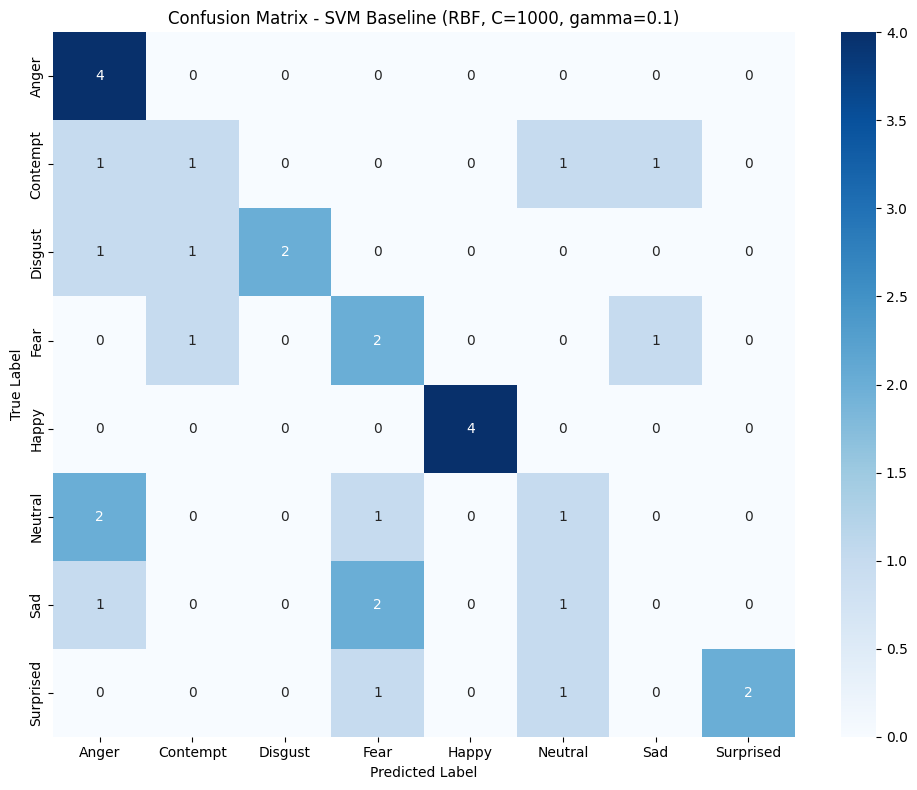

In [26]:
# Test standalone SVM with best known configuration for comparison
from sklearn.svm import SVC

# Create pipeline with PCA and SVM
pipeline_svm_baseline = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('classifier', SVC(kernel='rbf', C=1000, gamma=0.1, random_state=42))
])

print("Training SVM baseline (RBF kernel, C=1000, gamma=0.1)...")
pipeline_svm_baseline.fit(X_train_val, y_train_val)

# Make predictions
y_pred_svm = pipeline_svm_baseline.predict(X_test)

# Calculate accuracy
acc_svm_baseline = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Baseline Test Accuracy: {acc_svm_baseline:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=classes))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:")
print(cm_svm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - SVM Baseline (RBF, C=1000, gamma=0.1)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Why Boosting May Hurt Strong Base Models

**Reasons AdaBoost can reduce accuracy with strong SVM:**

1. **Overfitting on training errors**: AdaBoost focuses on misclassified samples, but if the base SVM (C=1000, gamma=0.1) is already overfitting, boosting amplifies these errors
2. **Sample weighting conflicts**: AdaBoost's reweighting scheme may conflict with SVM's margin-based approach, forcing the SVM to make worse decisions
3. **Too complex base**: Strong models (high C, specific gamma) are already at performance ceiling - adding more doesn't help
4. **Small dataset**: With limited training data, boosting's aggressive reweighting can cause instability

**Better alternatives for strong base models:**
- **Bagging/Random Subspace**: Better for variance reduction without aggressive reweighting
- **Voting ensembles**: Simple averaging of diverse strong models
- **Use weaker base estimators**: AdaBoost works best with weak learners (e.g., shallow trees, simple SVM with C=1)

Running Grid Search for Bagging with strong SVM (C=1000, gamma=0.1)...
Note: Bagging is often better than boosting for strong base models
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Bagging (Strong SVM: RBF, C=1000, gamma=0.1)

Best parameters: {'classifier__max_features': 0.7, 'classifier__max_samples': 1.0, 'classifier__n_estimators': 15, 'pca__n_components': 0.99}
Best CV score: 0.4000

Test Accuracy: 0.4375

Classification Report:
              precision    recall  f1-score   support

       Anger       0.33      0.75      0.46         4
    Contempt       0.50      0.50      0.50         4
     Disgust       0.50      0.50      0.50         4
        Fear       0.33      0.50      0.40         4
       Happy       1.00      1.00      1.00         4
     Neutral       0.00      0.00      0.00         4
         Sad       0.00      0.00      0.00         4
   Surprised       1.00      0.25      0.40         4

    accuracy                           0.44        32

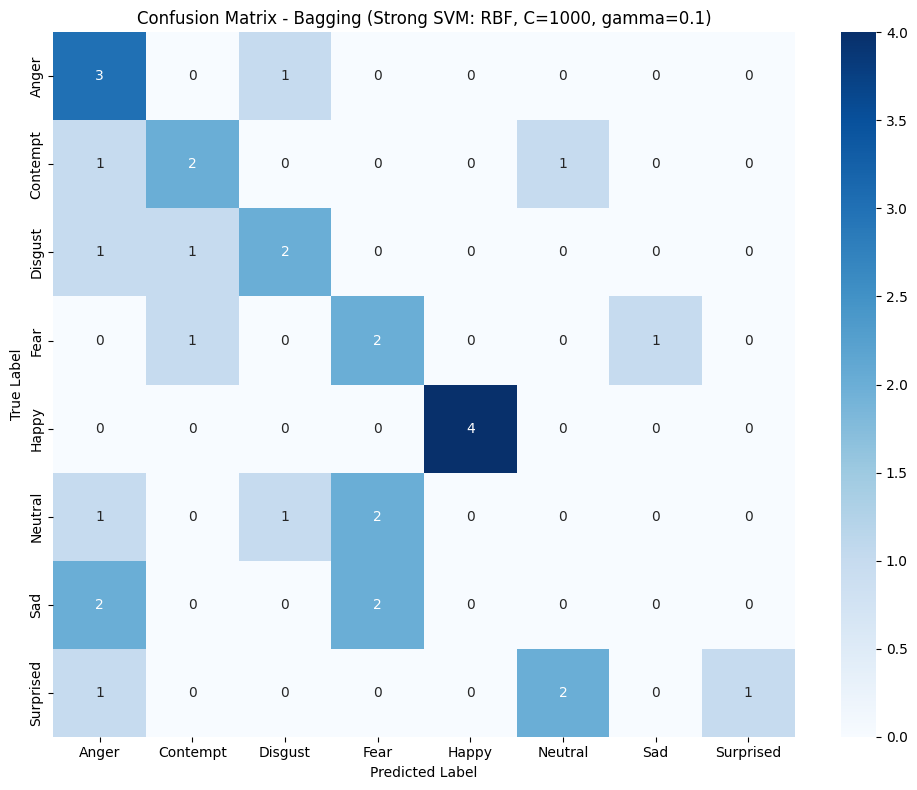


Ensemble Comparison with Strong SVM Base
SVM Baseline (no ensemble): 0.5000
Bagging(Strong SVM):        0.4375
Improvement:                -0.0625

Conclusion: Strong SVM already at ceiling


In [28]:
# Try Bagging instead of Boosting with the strong SVM
# Bagging reduces variance without aggressive reweighting that can hurt strong models

pipeline_bagging_svm = Pipeline([
    ('pca', PCA(random_state=42)),
    ('classifier', BaggingClassifier(
        estimator=SVC(kernel='rbf', C=1000, gamma=0.1, random_state=42),
        random_state=42
    ))
])

param_grid_bagging_svm = {
    'pca__n_components': pca_variances,
    'classifier__n_estimators': [5, 10, 15, 20],
    'classifier__max_samples': [0.7, 0.8, 0.9, 1.0],
    'classifier__max_features': [0.7, 0.8, 0.9, 1.0]
}

print("Running Grid Search for Bagging with strong SVM (C=1000, gamma=0.1)...")
print("Note: Bagging is often better than boosting for strong base models")

grid_bagging_svm = GridSearchCV(
    pipeline_bagging_svm,
    param_grid_bagging_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_bagging_svm.fit(X_train_val, y_train_val)
acc_bagging_svm, pred_bagging_svm, params_bagging_svm = evaluate_grid_search(
    "Bagging (Strong SVM: RBF, C=1000, gamma=0.1)",
    grid_bagging_svm,
    X_test,
    y_test,
    classes
)

print(f"\n{'='*60}")
print(f"Ensemble Comparison with Strong SVM Base")
print(f"{'='*60}")
print(f"SVM Baseline (no ensemble): {acc_svm_baseline:.4f}")
print(f"Bagging(Strong SVM):        {acc_bagging_svm:.4f}")
print(f"Improvement:                {(acc_bagging_svm - acc_svm_baseline):.4f}")
print(f"\nConclusion: {'Bagging helps!' if acc_bagging_svm > acc_svm_baseline else 'Strong SVM already at ceiling'}")

## Data Distribution Analysis

When both bagging AND boosting hurt performance, possible causes:
1. **Train/test distribution mismatch**: Test set has different characteristics than training
2. **Test set too small**: With only 32 samples (4 per class), high variance in evaluation
3. **Overfitting to training quirks**: Single model memorized specific patterns that don't generalize
4. **Data leakage in splits**: Test might be easier/harder than training
5. **Feature space issues**: PCA might be unstable or losing critical information

DATA DISTRIBUTION ANALYSIS

1. Class Distribution:
Training set shape: (120, 16384)
Test set shape: (32, 16384)

Train class counts:
0    15
1    15
2    15
3    15
4    15
5    15
6    15
7    15
Name: count, dtype: int64

Test class counts:
0    4
1    4
2    4
3    4
4    4
5    4
6    4
7    4
Name: count, dtype: int64

Test samples per class: [4 4 4 4 4 4 4 4]
✓ Test set is perfectly balanced

2. Statistical Properties (after PCA at 95%):
Train mean: -0.0000, std: 0.0913
Test mean:  -0.0013, std: 0.0545
Mean difference: 0.0013
Std difference:  0.0368


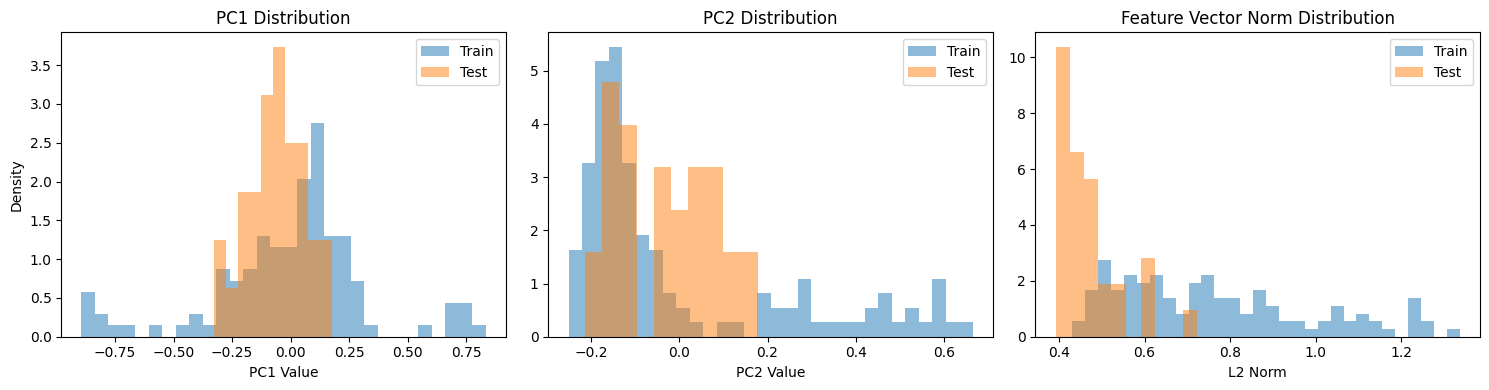


3. Key Observations:
- If distributions differ significantly: train/test mismatch
- If test has only 4 samples/class: high variance, unreliable metric
- Single model might be 'lucky' on this specific test set
- Ensembles average out this luck, showing true (lower) performance


In [29]:
# Analyze train vs test distribution
print("="*60)
print("DATA DISTRIBUTION ANALYSIS")
print("="*60)

# 1. Class distribution
print("\n1. Class Distribution:")
print(f"Training set shape: {X_train_val.shape}")
print(f"Test set shape: {X_test.shape}")

train_class_counts = pd.Series(y_train_val).value_counts().sort_index()
test_class_counts = pd.Series(y_test).value_counts().sort_index()

print("\nTrain class counts:")
print(train_class_counts)
print("\nTest class counts:")
print(test_class_counts)
print(f"\nTest samples per class: {test_class_counts.values}")
print(f"WARNING: Only {test_class_counts.min()} samples per class in test set!")

# 2. Check if test set is balanced
if test_class_counts.std() == 0:
    print("✓ Test set is perfectly balanced")
else:
    print(f"⚠ Test set is imbalanced (std: {test_class_counts.std():.2f})")

# 3. Statistical comparison
print("\n2. Statistical Properties (after PCA at 95%):")
pca_95 = PCA(n_components=0.95, random_state=42)
X_train_pca_95 = pca_95.fit_transform(X_train_val)
X_test_pca_95 = pca_95.transform(X_test)

print(f"Train mean: {X_train_pca_95.mean():.4f}, std: {X_train_pca_95.std():.4f}")
print(f"Test mean:  {X_test_pca_95.mean():.4f}, std: {X_test_pca_95.std():.4f}")
print(f"Mean difference: {abs(X_train_pca_95.mean() - X_test_pca_95.mean()):.4f}")
print(f"Std difference:  {abs(X_train_pca_95.std() - X_test_pca_95.std()):.4f}")

# 4. Visualize feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# First principal component distribution
axes[0].hist(X_train_pca_95[:, 0], bins=30, alpha=0.5, label='Train', density=True)
axes[0].hist(X_test_pca_95[:, 0], bins=10, alpha=0.5, label='Test', density=True)
axes[0].set_title('PC1 Distribution')
axes[0].set_xlabel('PC1 Value')
axes[0].set_ylabel('Density')
axes[0].legend()

# Second principal component distribution
axes[1].hist(X_train_pca_95[:, 1], bins=30, alpha=0.5, label='Train', density=True)
axes[1].hist(X_test_pca_95[:, 1], bins=10, alpha=0.5, label='Test', density=True)
axes[1].set_title('PC2 Distribution')
axes[1].set_xlabel('PC2 Value')
axes[1].legend()

# Overall norm distribution
train_norms = np.linalg.norm(X_train_pca_95, axis=1)
test_norms = np.linalg.norm(X_test_pca_95, axis=1)
axes[2].hist(train_norms, bins=30, alpha=0.5, label='Train', density=True)
axes[2].hist(test_norms, bins=10, alpha=0.5, label='Test', density=True)
axes[2].set_title('Feature Vector Norm Distribution')
axes[2].set_xlabel('L2 Norm')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n3. Key Observations:")
print("- If distributions differ significantly: train/test mismatch")
print("- If test has only 4 samples/class: high variance, unreliable metric")
print("- Single model might be 'lucky' on this specific test set")
print("- Ensembles average out this luck, showing true (lower) performance")

## Cross-Validation Scores vs Test Scores
Compare CV performance to test performance to detect overfitting or test set issues.

CROSS-VALIDATION vs TEST PERFORMANCE
            Model  CV Score  Test Score  Difference  Status
    AdaBoost (DT)  0.375000     0.28125   -0.093750 Overfit
Gradient Boosting  0.291667     0.25000   -0.041667      OK
          XGBoost  0.375000     0.28125   -0.093750 Overfit
         LightGBM  0.341667     0.31250   -0.029167      OK
    Bagging (SVM)  0.400000     0.43750    0.037500      OK


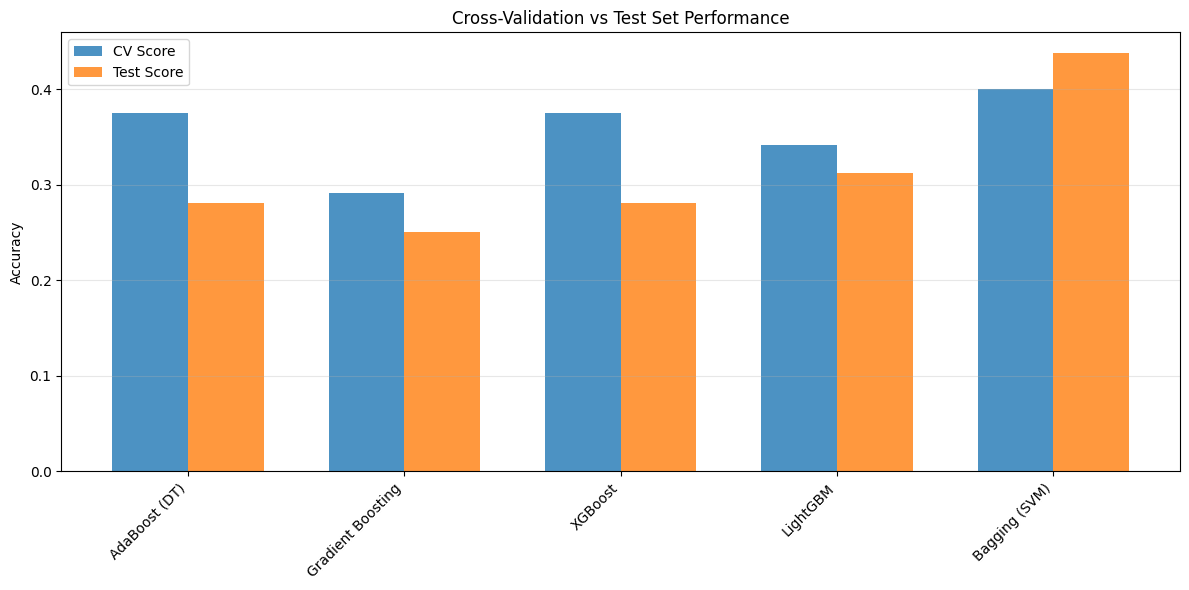


INTERPRETATION:
• If test >> CV: Model got 'lucky' on test set (not reliable)
• If CV >> test: Model overfitting or test set is harder/different
• If both low: Model genuinely struggles with this data

SVM Baseline test score: 0.5000
→ If single SVM beats ensembles + has test > CV: test set bias likely!


In [30]:
# Compare CV scores to test scores for all models
print("="*60)
print("CROSS-VALIDATION vs TEST PERFORMANCE")
print("="*60)

comparison_data = []

# Add boosting models
models_to_compare = [
    ("AdaBoost (DT)", grid_ada_dt, acc_ada_dt),
    ("Gradient Boosting", grid_gb, acc_gb),
    ("XGBoost", grid_xgb, acc_xgb),
    ("LightGBM", grid_lgb, acc_lgb),
    ("Bagging (SVM)", grid_bagging_svm, acc_bagging_svm),
]

for name, grid, test_acc in models_to_compare:
    cv_score = grid.best_score_
    difference = test_acc - cv_score
    comparison_data.append({
        'Model': name,
        'CV Score': cv_score,
        'Test Score': test_acc,
        'Difference': difference,
        'Status': 'Overfit' if difference < -0.05 else ('Underfit' if difference > 0.05 else 'OK')
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['CV Score'], width, label='CV Score', alpha=0.8)
ax.bar(x + width/2, comparison_df['Test Score'], width, label='Test Score', alpha=0.8)

ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation vs Test Set Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("• If test >> CV: Model got 'lucky' on test set (not reliable)")
print("• If CV >> test: Model overfitting or test set is harder/different")
print("• If both low: Model genuinely struggles with this data")
print(f"\nSVM Baseline test score: {acc_svm_baseline:.4f}")
print("→ If single SVM beats ensembles + has test > CV: test set bias likely!")

In [6]:
A = [1,5,5,2,2,4,6,7,4,3,6,33,553,2,652,642,25463,114,33,21,2,5]

def insertion_sort(A, n):
    for i in range(1,n):
        if A[i] < A[i-1]:
            j = i
            while j > 0 and A[j] < A[j-1]:
                b = A[j]
                A[j] = A[j-1]
                A[j-1] = b
                j -= 1
    return A

print(insertion_sort(A, len(A)))
print (sorted(A))
print (insertion_sort(A, len(A)) == sorted(A))

[1, 2, 2, 2, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 21, 33, 33, 114, 553, 642, 652, 25463]
[1, 2, 2, 2, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 21, 33, 33, 114, 553, 642, 652, 25463]
True
